# ASDF / WelDX Einführung

In [1]:
# if the package is not installed in your python environment, run this to execute the notebook directly from inside the GitHub repository
%cd -q ..

In [2]:
import asdf

import weldx
from weldx.asdf.utils import _write_buffer, _read_buffer, notebook_fileprinter

## ASDF (Advanced Scientific Data Format)
### Python API
- [Dokumentation](https://asdf.readthedocs.io/)
- [GitHub](https://github.com/asdf-format/asdf)

### Dateiformat / Dateistandard
- [Dokumentation](https://asdf-standard.readthedocs.io/)
- [GitHub](https://github.com/asdf-format/asdf-standard)

### in a nutshell
- ASDF ist ein hybrides Dateiformat mit einem YAML Header und angehängtem Binärteil
- Der Inhalt in ASDF Dateien ist immer in einer Baum-Struktur aufgebaut
- Grundsätzlich bestehen ASDF Dateien aus sehr einfachen Elementen, die beliebig verschachtelt und kombiniert werden können:
  - Nummern
  - Strings
  - Listen
  - Bäume
- Der ASDF Standard definiert den Aufbau und die Struktur einer ASDF Datei


Eine Beispieldatei:
```yaml
#ASDF_STANDARD 1.5.0
%YAML 1.1
%TAG ! tag:stsci.edu:asdf/

Eine Beispieldatei:
--- !core/asdf-1.1.0
asdf_library: !core/software-1.0.0 {author: Space Telescope Science Institute, homepage: 'http://github.com/spacetelescope/asdf',
  name: asdf, version: 2.7.1}
history:
  extensions:
  - !core/extension_metadata-1.0.0
    extension_class: asdf.extension.BuiltinExtension
    software: !core/software-1.0.0 {name: asdf, version: 2.7.1}

Anfang: Hello World!
Kreiszahl: 3.14
Liste: [1, 2, 3]
...
```

### Tags und Schemas
- Ein `tag` definiert einen Abschnitt bzw. ein Objekt in einer ASDF Datei, der ein bestimmtes Objekt abbildet
- Beispiel für das `tag` `!core/software-1.0.0`:
  ```yaml
  software: !core/software-1.0.0 {name: asdf, version: 2.7.1}
  ```
- In ASDF gibt es das Konzept von **Schemas**
- Schemas definieren, wie ein bestimmtes Element (ein `tag`) in der ASDF Datei strukturiert sein **muss**
- Beispiel für das `tag` `!core/software-1.0.0`:

```yaml
%YAML 1.1
---
$schema: "http://stsci.edu/schemas/yaml-schema/draft-01"
id: "http://stsci.edu/schemas/asdf/core/software-1.0.0"
title: |
  Describes a software package.
description: |
  General-purpose description of a software package.

tag: "tag:stsci.edu:asdf/core/software-1.0.0"
type: object
properties:
  name:
    description: |
      The name of the application or library.
    type: string

  author:
    description: |
      The author (or institution) that produced the software package.
    type: string

  homepage:
    description: |
      A URI to the homepage of the software.
    type: string
    format: uri

  version:
    description: |
      The version of the software used.  It is recommended, but not
      required, that this follows the (Semantic Versioning
      Specification)[http://semver.org/spec/v2.0.0.html].
    type: string

required: [name, version]
additionalProperties: true
...
```

### Python API
- Die `asdf` Bibliothek ermöglicht das schreiben und lesen von ASDF Dateien in Python
- der "tree" in einer ASDF Datei entspricht einem Python `dict`
- Die ASDF Datei ist also nichts weiter als eine bestimmte Serialisierung eines Python `dict`
- Die Standardtypen (nummern, strings, Listen, Dictionaries) werden direkt unterstützt

In [3]:
import numpy as np

tree = {"Anfang":"Hello World!",
        "Kreiszahl":3.14,
        "Liste":[1,2,3],
        "Zusatz":
            {"Frage":"Was ist die Lösung?","Antwort":42},
        "array":np.arange(5)
       }
buffer = _write_buffer(tree)
notebook_fileprinter(buffer)

- Im Zusammenspiel aus dem Dateiformat und einer API sind die Tags einzelnen Klassen der Programmiersprache zugewiesen.
- Die Schemas bestimmen also, in welcher Struktur bestimmte Objekte in einer ASDF Datei serialisiert werden müssen.
- Beim Einlesen der Datei werden die `tags` wieder in die passenden Python-Objekte zurück serialisiert.
- Für jede Python Klasse (außer Standardtypen) muss also ein Schema vorliegen dass die Struktur beschreibt und die ASDF API muss wissen wie die Python Objekte ASDF konform serialisiert werden können.

## WelDX
- WelDX besteht im Wesentlichen aus zwei getrennten Teilen die miteinander verknüpft sind
- WelDX ist zunächst mal eine Python-Bibliothek
  - Die WelDX API stellt bestimmte Funktionen und Klassen bereit, um Schweißaufgaben zu beschreiben, Auszuwerten, visualisieren etc.
- Zusätzlich definiert WelDX die zugehörigen ASDF Schema Beschreibungen
  - Wie werden die Python Objekte in ASDF serialisiert
  - Welche Angaben zu Versuchen, Messungen etc. **müssen** oder **können** in welcher Form angegeben werden
  - die Schemata können hier angesehen werden: [WelDX Standard](https://weldx.readthedocs.io/en/latest/standard.html)
- Das Ziel beim Dateiformat ist, dass sich die Community in der Schweißtechnik auf einheitliche Strukturen und Beschreibungen der Daten einigt
- Die Schemas können auch sehr einfach angepasst oder ergänzt werden

Ein Beispiel:

In [4]:
from weldx import Q_
from weldx.welding.groove.iso_9692_1 import get_groove

groove = get_groove(
    groove_type="VGroove",
    workpiece_thickness=Q_(5, "mm"),
    groove_angle=Q_(45, "deg"),
    root_face=Q_(1.5, "mm"),
    root_gap=Q_(1, "mm"),
)

str(groove)

"VGroove(t=<Quantity(5, 'millimeter')>, alpha=<Quantity(45, 'degree')>, c=<Quantity(1.5, 'millimeter')>, b=<Quantity(1, 'millimeter')>, code_number=['1.3', '1.5'])"

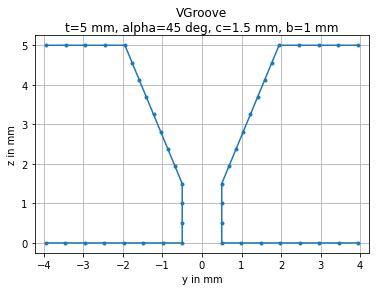

In [5]:
groove.plot()

In [6]:
tree = {"Nahtvorbereitung":groove}
buffer = _write_buffer(tree)
notebook_fileprinter(buffer)

Das zugehörige ASDF Schema findet man [hier](https://weldx.readthedocs.io/en/latest/generated/weldx.bam.de/weldx/groove/iso_9692_1_2013_12/VGroove-1.0.0.html)

```yaml
%YAML 1.1
---
$schema: "http://stsci.edu/schemas/yaml-schema/draft-01"
id: "http://weldx.bam.de/schemas/weldx/groove/iso_9692_1_2013_12/VGroove-1.0.0"
tag: "tag:weldx.bam.de:weldx/groove/iso_9692_1_2013_12/VGroove-1.0.0"

title: |
  VGroove representation.

type: object
properties:
  t:
    description: |
      The workpiece thickness.
    $ref: "../terms-1.0.0#/definitions/workpiece-thickness"
  alpha:
    description: |
      The full groove angle.
    $ref: "../terms-1.0.0#/definitions/groove-angle"
  b:
    description: |
      The root gap between both plates.
    $ref: "../terms-1.0.0#/definitions/root-gap"
  c:
    description: |
      The root face.
    $ref: "../terms-1.0.0#/definitions/root-face"
required: [t, alpha, b, c]
propertyOrder: [t, alpha, b, c]
...
```

Die Datei kann auch einfach wieder eingelesen werden:

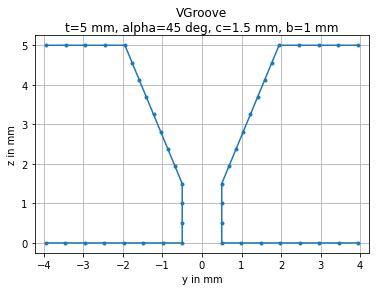

In [9]:
data =  _read_buffer(buffer)
data["Nahtvorbereitung"]